# Symbolic regression with DEAP

In [200]:
import operator
import math
import random
import numpy as np
import matplotlib.pyplot as plt

from deap import base, creator, tools, gp, algorithms

Create a dataset:

In [201]:
def target_function(x):
    return np.sin(2*x) 
N = 100
noise = 0.1
X = np.linspace(-4,4,N) 
y = target_function(X) + noise *np.random.randn(N)

Define allowed operations:

In [202]:
pset = gp.PrimitiveSet("MAIN", 1)

pset.addPrimitive(operator.add, 2)
pset.addPrimitive(operator.sub, 2)
pset.addPrimitive(operator.mul, 2)

def protected_div(x, y):
    return x / y if y != 0 else 1

pset.addPrimitive(protected_div, 2)

pset.addPrimitive(math.sin, 1)
pset.addPrimitive(math.cos, 1)

pset.addEphemeralConstant("rand101", lambda: random.uniform(-1,1))

pset.renameArguments(ARG0="x")

Define individuals (genotypes):

In [203]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", gp.PrimitiveTree, fitness= creator.FitnessMin)

"Evolution engine":

In [204]:
toolbox = base.Toolbox()

toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=2)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

Fitness function:

In [205]:
def eval_symb_reg(individual):
    
    func = toolbox.compile(expr=individual)
    
    predictions = []
    
    for x_val in X:
        try:
            predictions.append(func(x_val))
        except:
            return (float("inf"),)
    
    predictions = np.array(predictions)
    return (np.mean((y - predictions)**2),)

toolbox.register("compile", gp.compile, pset=pset)
toolbox.register("evaluate", eval_symb_reg)

Evolution operators:

In [206]:
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr, pset=pset)


Control tree growth:

In [207]:
toolbox.decorate("mate", gp.staticLimit(key=len, max_value=17))
toolbox.decorate("mutate", gp.staticLimit(key=len, max_value=17))

## Run evolution

In [208]:
population = toolbox.population(n=300)

hof = tools.HallOfFame(1)

stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("min", np.min)

population, log = algorithms.eaSimple(
    population,
    toolbox,
    cxpb=0.5,
    mutpb=0.2, 
    ngen=40, 
    stats=stats,
    halloffame=hof,
    verbose=True
)

gen	nevals	avg    	min    
0  	300   	29.2529	0.48751
1  	175   	4156.56	0.48751
2  	205   	7.91356	0.48751
3  	175   	14356.8	0.493645
4  	163   	4.16855	0.493645
5  	183   	571821 	0.493645
6  	182   	57.6494	0.500083
7  	175   	290.245	0.347837
8  	194   	2045.29	0.480907
9  	184   	2.07166	0.481032
10 	189   	9.95887	0.156693
11 	181   	56.9587	0.133175
12 	185   	1.0122 	0.133233
13 	164   	0.720709	0.133233
14 	177   	1.44361 	0.130716
15 	179   	9.62543 	0.133233
16 	169   	19.1083 	0.133233
17 	168   	8.10922 	0.133233
18 	178   	5.73454 	0.133233
19 	176   	20.3355 	0.133233
20 	166   	12.182  	0.133233
21 	187   	4.76376 	0.133233
22 	199   	50.0649 	0.131294
23 	181   	7.23386 	0.131294
24 	175   	5.29012 	0.131294
25 	157   	3.24991 	0.112542
26 	172   	2.00052 	0.112542
27 	177   	7.60768 	0.0825072
28 	184   	1.98283 	0.0825072
29 	169   	1.49542 	0.0825072
30 	175   	3.98569 	0.0113713
31 	197   	2.56894 	0.0113713
32 	169   	1.94611 	0.0113713
33 	177   	2.88703 	0.0113

In [209]:
best = hof[0]
print("Best expression:", best)

Best expression: mul(sin(x), add(cos(x), protected_div(cos(x), protected_div(x, mul(sub(x, x), x)))))


In [210]:
toolbox.compile(best)

<function <lambda>(x)>

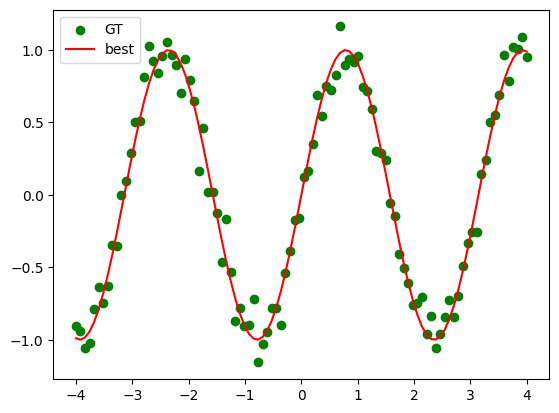

In [211]:
func = toolbox.compile(best)
y_pred = [func(x) for x in X]

plt.scatter(X, y, label="GT", color="green")
plt.plot(X, y_pred, label="best", color="red")
plt.legend()
plt.show()